# Week 8 - Trees and Ensembles

**Siqi Wang s2823896, Wenhui Yu s2803003, Yichen Zhang s2804697**

### Aims

By the end of this notebook you will be able to understand: 

>* The Basics of Decision Trees
>* Cost Complexity Pruning
>* Ensembles (bagging, random forests, voting)


1. [Setup](#setup)

2. [Decision Trees](#intro)

3. [Ensembles](#majVot)

As usual, during workshops, you will complete the worksheets together in teams of 2-3, using **pair programming**. When completing worksheets:

>- You will have tasks tagged by (CORE) and (EXTRA). 
>- Your primary aim is to complete the (CORE) components during the WS session, afterwards you can try to complete the (EXTRA) tasks for your self-learning process. 
>- In some Exercises, you will see some hints at the bottom of questions.

Instructions for submitting your workshops can be found at the end of worksheet. As a reminder, you must submit a pdf of your notebook on Learn by 16:00 PM on the Friday of the week the workshop was given.

# Setup <a id='setup'></a>

Let's load the packages needed for this workshop (more will be loaded through the workshop).

In [1]:
# Display plots inline
%matplotlib inline  

# Data libraries
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn modules
import sklearn
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# some new libraries and modules for this week
from sklearn.tree import export_graphviz, DecisionTreeClassifier

# Introduction to Decision Trees <a id='intro'></a>

Decision trees provide a simple, interpretable model for both classification and regression tasks. They are able to capture nonlinear relationships between the features and target variables, by learning simple decision rules and assuming piecewise constant approximations. The deeper the tree, the more complex the decision rules and the better the fit on the training data.

Decision trees require little preprocessing and feature engineering. While other methods often require standardization, this is not the case for trees, and some tree and algorithm combinations can even support missing values. Decision trees able to handle both numerical and categorical data. However, sklearn does not implent more advanced methods for multi-class categorical features, and one-hot encoding must be used; if the number of features is large, this may result in many features and complex trees that suffer from overfitting. 

To learn the decision tree, sklearn uses an optimized version of the Classification and Regression Tree (CART) algorithm, which is a greedy algorithm where locally optimal decisions are made at each node, starting from the root down to the leaves. At each node/step, CART uses binary spliting and finds the threshold yielding the largest information gain. For more information on sklearn's implementation of decision trees, see https://scikit-learn.org/stable/modules/tree.html#tree-classification.

The sklearn implementation supports both regression tasks through [`DecisionTreeRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html#sklearn.tree.DecisionTreeRegressor) and classication through [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier). In this workshop, we will focus on **classification**. 

Let's start by loading data to explore the `DecisionTreeClassifier`.

##  Palmer Penguin Data

The palmer penguins dataset contains information for 344 penguins from 3 different species and from 3 islands in the Palmer Archipelago, Antarctica.

In [2]:
# Load the data
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


Let's start with some basic EDA.

In [3]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


Notice that there are some missing values. For simplicity, we will remove them.  

In [4]:
# dropna values
penguins_rm = penguins.dropna()
penguins_rm.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


We will focus on the task of classifying species. Notice that there are four numerical features and two categorical features. For simplicity, we will focus on the numerical features only. Before any further EDA, we split our data into a training and test set.

In [5]:
# Split into train and test sets

# Feature matrix and response vector
X, y = penguins_rm.drop(["island", "sex", "species"], axis=1), penguins_rm['species']

# Stratify split
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle= True, test_size = 0.2, random_state=0)

### 🚩 Exercise 1 (CORE)

- Draw a pairplot, setting `hue = "species"`, to explore the numerical features relation with species. 
- Comment on any relationships that you observe.


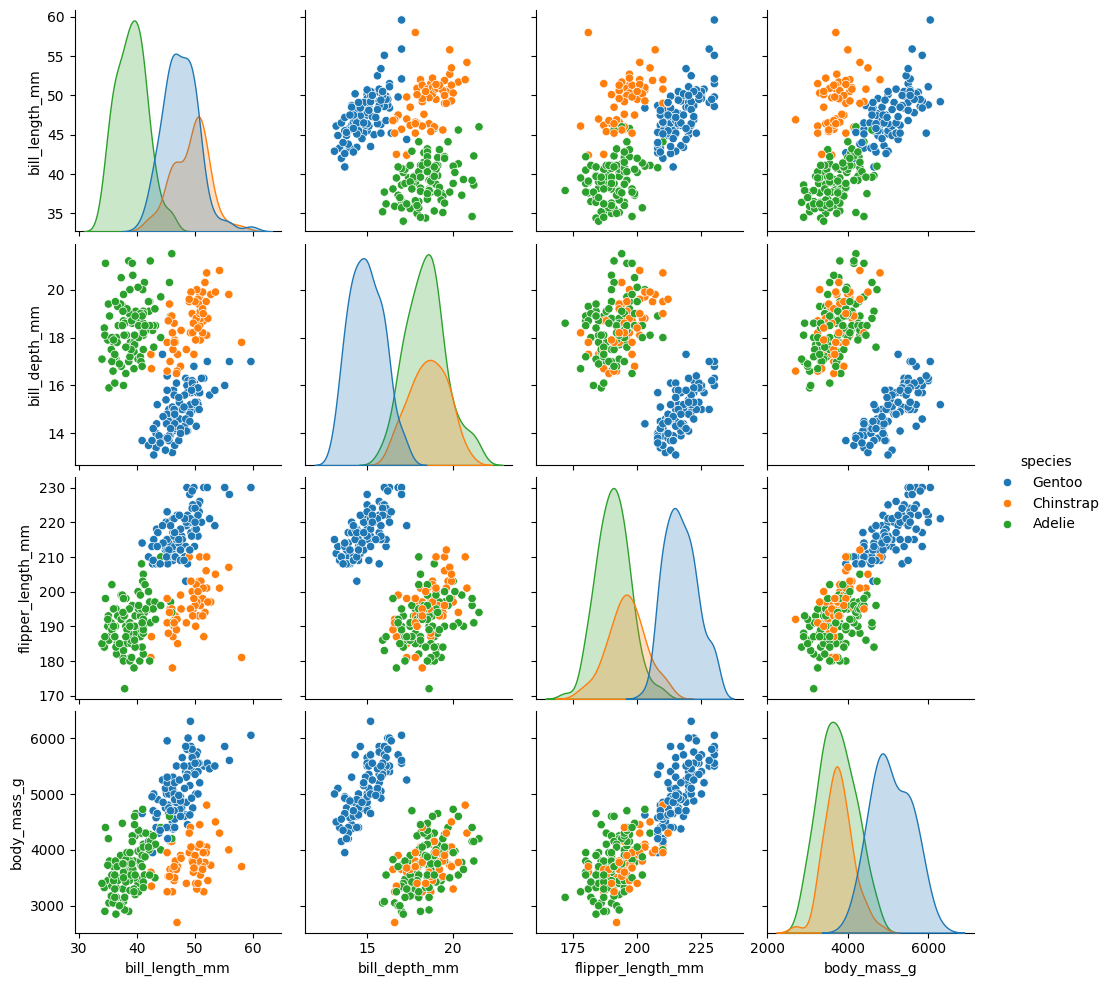

In [6]:
# Code for your answer here
train_data = X_train.copy()
train_data['species'] = y_train

sns.pairplot(train_data, hue="species")

_Gentoo is highly distinct: Looking at the density curves on the diagonal and the scatter plots, Gentoo penguins are clearly separated from the other two species. They are significantly heavier, have longer flippers, and shallower bill depths. In any 2D scatter plot involving flipper length or body mass, Gentoo forms an isolated cluster.\
Distinguishing Adelie and Chinstrap: Adelie and Chinstrap overlap heavily in body mass, flipper length, and bill depth, making them hard to distinguish using those features. However, looking at the first row/column, they can be clearly differentiated by bill_length_mm: Chinstraps have noticeably longer bills than Adelies.\
Strong Positive Correlation: Across all species, there is a strong positive correlation between flipper_length_mm and body_mass_g—heavier penguins tend to have longer flippers.\
Implications for Decision Trees: The clear separation seen in the density plots makes this dataset ideal for decision tree algorithms. A tree will likely use flipper length or body mass to split out the Gentoo species at the root node, and then use bill length in a subsequent node to separate Adelie from Chinstrap._

## Classification Trees

Recall from lectures, the decision tree has a number of parameters that affect the shape of the tree:

- `max_depth` : the maximum depth of the tree. 

- `min_samples_split` : the minimum number of samples required to split an internal node

- `min_samples_leaf`: the minimum number of samples required to be at a leaf node. A split point at any depth will only be considered if it leaves at least min_samples_leaf training samples in each of the left and right branches. 

- `max_leaf_nodes`: the maximum number of leaf nodes. 

- `min_impurity_decrease`: A node will be split if this split induces a decrease of the impurity greater than or equal to this value.

As usual, once we create our `DecisionTreeClassifier` object, we can fit the tree by calling `.fit()`. Once fit, the tree will have a number of attributes and we can call additional methods such as `.predict()` or  `.predict_proba()` to predict hard or soft labels, respectively, for any new data. 

Let's fit our first decision tree. In the following code, we fit a simple tree of depth 2 by specifying `max_depth=2`. 

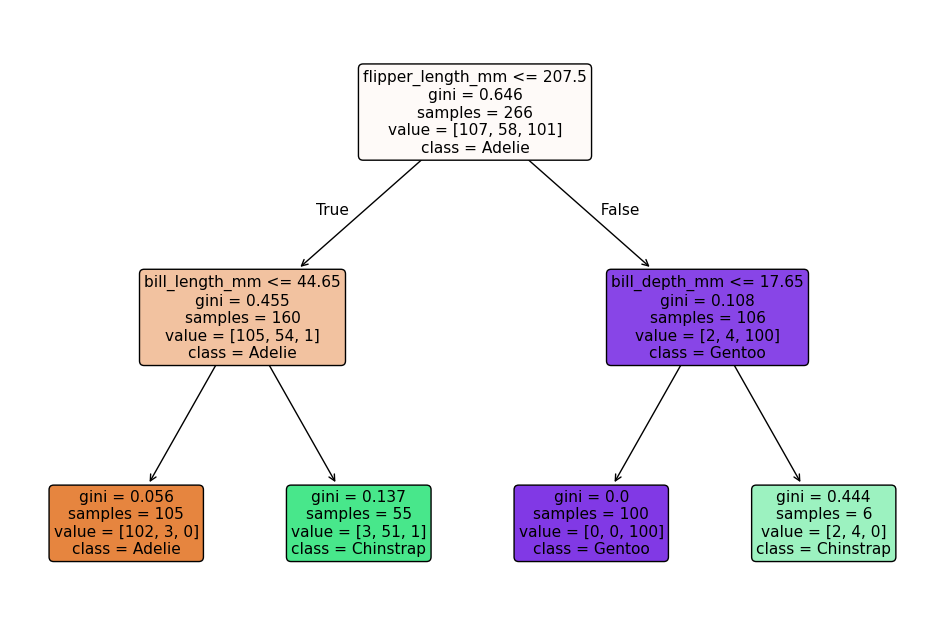

In [7]:
# Decsion tree with max depth of 2
tree_clf = DecisionTreeClassifier(max_depth = 2)
tree_clf.fit(X_train, y_train)

# Plot the decision tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Set the figure size to make the tree easy to read
plt.figure(figsize=(12, 8))

# Plot the tree directly
plot_tree(
    tree_clf, 
    filled=True, 
    rounded=True, 
    feature_names=X_train.columns, 
    class_names=tree_clf.classes_
)

plt.show()

**NOTE:** If you working locally and [inkscape](https://inkscape.org/release/inkscape-1.4/) is not installed, you will have issues in exporting the notebook to PDF when graphviz images are included. In this case, please either install inkscape or use the `plot_tree` function below to plot the tree instead. 

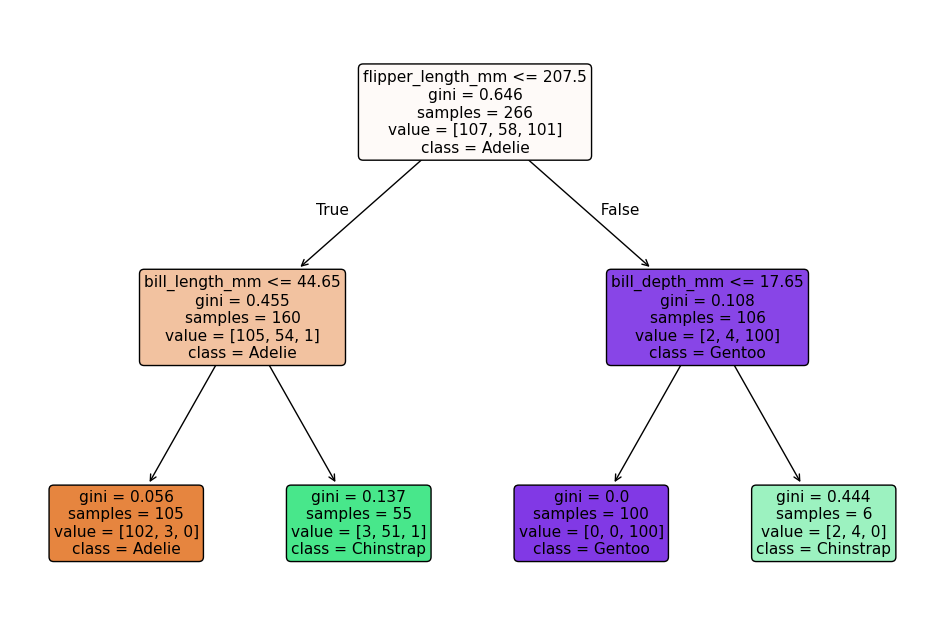

In [8]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(tree_clf, rounded = True, filled = True, feature_names=X_train.columns, class_names = tree_clf.classes_)
plt.show()

### 🚩 Exercise 2  (CORE)

Below, we print out the first five rows of the test data. Based on the fitted tree above (not using `.predict()`!!), what is the classified species of each penguin/row? what path along the decision tree is taken to classify the penguin?

In [9]:
X_test.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
62,37.6,17.0,185.0,3600.0
60,35.7,16.9,185.0,3150.0
283,54.3,15.7,231.0,5650.0
107,38.2,20.0,190.0,3900.0
65,41.6,18.0,192.0,3950.0


_Index 62 Features: flipper_length_mm = 185.0, bill_length_mm = 37.6Path: 185.0 <= 207.5 is True (Left) $\rightarrow$ 37.6 <= 44.65 is True (Left) Prediction: Adelie\
Index 60 Features: flipper_length_mm = 185.0, bill_length_mm = 35.7Path: 185.0 <= 207.5 is True (Left) $\rightarrow$ 35.7 <= 44.65 is True (Left) Prediction: Adelie\
Index 283 Features: flipper_length_mm = 231.0, bill_depth_mm = 15.7Path: 231.0 <= 207.5 is False (Right) $\rightarrow$ 15.7 <= 17.65 is True (Left) Prediction: Gentoo\
Index 107 Features: flipper_length_mm = 190.0, bill_length_mm = 38.2Path: 190.0 <= 207.5 is True (Left) $\rightarrow$ 38.2 <= 44.65 is True (Left) Prediction: Adelie\
Index 65 Features: flipper_length_mm = 192.0, bill_length_mm = 41.6Path: 192.0 <= 207.5 is True (Left) $\rightarrow$ 41.6 <= 44.65 is True (Left) Prediction: Adelie_

### 🚩 Exercise 3  (CORE) 

Fit a new decision tree, again with a depth 2, but change the criterion to measure the quality of a split to entropy. How has the tree stucture changed?

**Hint:** when creating the decision tree object, set the option `criterion`.

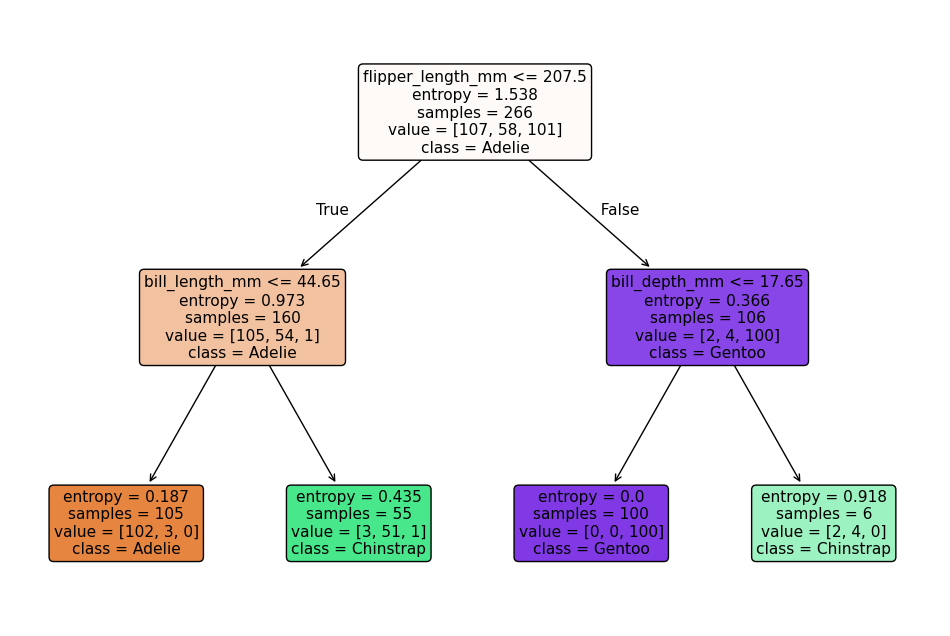

In [10]:
# Code for your answer here
tree_clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=0)

tree_clf_entropy.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
plot_tree(
    tree_clf_entropy,
    filled=True,
    rounded=True,
    feature_names=X_train.columns,
    class_names=tree_clf_entropy.classes_
)
plt.show()

_The tree structure has not changed at all. If we compare this tree to the one from Exercise 1, we will notice: Identical Splits: The tree chose the exact same features for splitting at every node (flipper_length_mm, bill_length_mm, and bill_depth_mm). Identical Thresholds: The numerical thresholds for those splits are exactly the same (<= 207.5, <= 44.65, and <= 17.65). Identical Leaves: The number of samples and the final class distributions in each leaf node remain perfectly unchanged.\
The only thing that changed is the impurity metric printed inside the boxes. The model calculated entropy instead of Gini impurity to evaluate the quality of the splits. In practice, Gini and entropy yield the exact same tree structure most of the time, which is exactly what happened here._

### 🚩 Exercise 4  (CORE) 

- Create two functions, one to compute the Gini index and another to compute the entropy, based on a vector of counts representing the number of observations in each category. 

- For each leaf node in the trees fitted above, use your functions to compute the Gini index and entropy based on the counts reported. If your functions are correct, it should match the numbers reported in the tree.

**RECALL**

- **Gini Index**: is a measure of total variance across the $C$ classes, defined as:

$G(R_m) = \sum_{c=1}^{C} \widehat{p}_{m,c} (1 - \widehat{p}_{m,c}) = 
1 - \sum_{c=1}^{C} \widehat{p}_{m,c}^2$ 

where $\widehat{p}_{m,c}$ is the proportion of training observations in the $m$ th region (belonging to $m$ th node) coming from the $c$ th class.

- **Entropy**: is an information theoretic measure defined as:

$H(R_m) = - \sum_{c=1}^{C} \widehat{p}_{m,c} \log_2 \widehat{p}_{m,c}.$

In [11]:
# Code for your answer here
import numpy as np

def compute_gini(counts):
    counts = np.array(counts)
    total = counts.sum()
    if total == 0:
        return 0.0
    
    proportions = counts / total
    gini = 1.0 - np.sum(proportions ** 2)
    return gini

def compute_entropy(counts):
    counts = np.array(counts)
    total = counts.sum()
    if total == 0:
        return 0.0
    
    proportions = counts / total
    non_zero_props = proportions[proportions > 0]
    entropy = -np.sum(non_zero_props * np.log2(non_zero_props))
    return entropy

leaf_nodes = [
    [102, 3, 0],   # Leaf 1 (Far Left - Adelie)
    [3, 51, 1],    # Leaf 2 (Middle Left - Chinstrap)
    [0, 0, 100],   # Leaf 3 (Middle Right - Gentoo)
    [2, 4, 0]      # Leaf 4 (Far Right - Chinstrap)
]

for i, leaf in enumerate(leaf_nodes):
    gini_val = compute_gini(leaf)
    entropy_val = compute_entropy(leaf)
    
    print(f"Leaf {i+1} counts: {leaf}")
    print(f"  -> Gini:    {gini_val:.3f}")
    print(f"  -> Entropy: {entropy_val:.3f}\n")

Leaf 1 counts: [102, 3, 0]
  -> Gini:    0.056
  -> Entropy: 0.187

Leaf 2 counts: [3, 51, 1]
  -> Gini:    0.137
  -> Entropy: 0.435

Leaf 3 counts: [0, 0, 100]
  -> Gini:    0.000
  -> Entropy: -0.000

Leaf 4 counts: [2, 4, 0]
  -> Gini:    0.444
  -> Entropy: 0.918



Note that our fitted `DecisionTreeClassifier` stores the tree as an attribute, which can be accessed by calling `.tree_`. For more information on how `sklearn` stores a tree, see [here](https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html#sphx-glr-auto-examples-tree-plot-unveil-tree-structure-py). The fitted tree has a number of attributes, including `.impurity` providing the impurity for all nodes.    

In [12]:
# The impurity values for all nodes are accessible in the impurity attribute of the tree.
print(tree_clf.tree_.impurity)
print(tree_clf_entropy.tree_.impurity)

[0.64647521 0.45539063 0.0555102  0.1368595  0.10822357 0.
 0.44444444]
[1.5380673  0.97342994 0.18717626 0.4350219  0.36579197 0.
 0.91829583]


### 🚩 Exercise 5 (CORE)

Trying increasing the maximum depth to 10.

- Fit and visualize the tree.

- What is the depth of the tree? **Hint**: check the available methods for a `DecisionTreeClassifier`. 

- How does the accuracy on both the train and test data compare with our previous tree with a depth of 2?

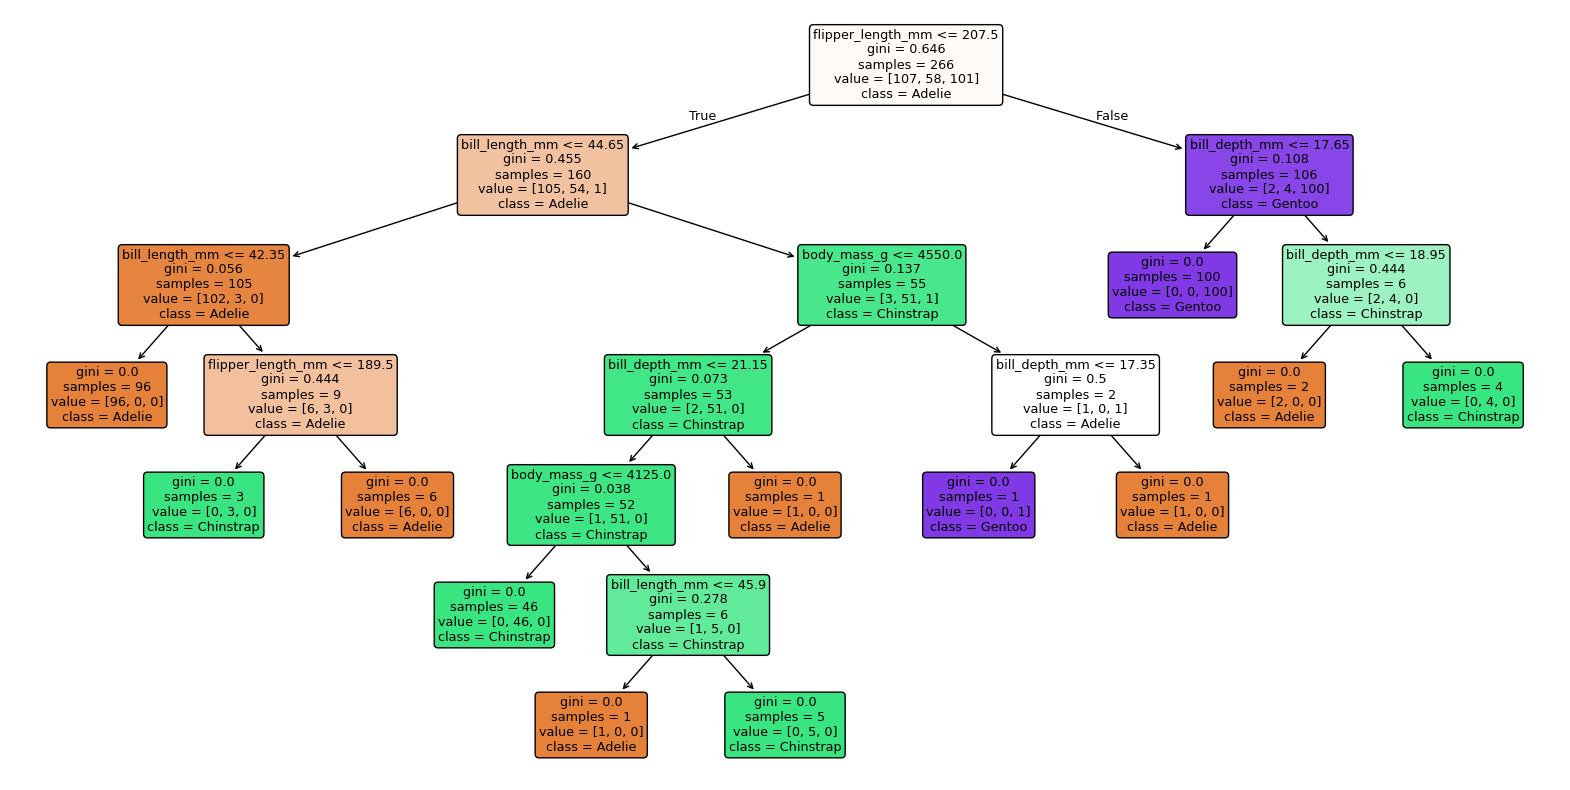

The actual depth of the fitted tree is: 6
Tree (max_depth=10) -> Train: 1.0000 | Test: 0.9701
Tree (max_depth=2)  -> Train: 0.9662 | Test: 0.9403


In [13]:
# Code for your answer here
tree_clf_10 = DecisionTreeClassifier(max_depth=10, random_state=0)
tree_clf_10.fit(X_train, y_train)

plt.figure(figsize=(20, 10)) 
plot_tree(
    tree_clf_10,
    filled=True,
    rounded=True,
    feature_names=X_train.columns,
    class_names=tree_clf_10.classes_
)
plt.show()

actual_depth = tree_clf_10.get_depth()
print(f"The actual depth of the fitted tree is: {actual_depth}")

train_acc_10 = tree_clf_10.score(X_train, y_train)
test_acc_10 = tree_clf_10.score(X_test, y_test)

train_acc_2 = tree_clf.score(X_train, y_train)
test_acc_2 = tree_clf.score(X_test, y_test)

print(f"Tree (max_depth=10) -> Train: {train_acc_10:.4f} | Test: {test_acc_10:.4f}")
print(f"Tree (max_depth=2)  -> Train: {train_acc_2:.4f} | Test: {test_acc_2:.4f}")

_The actual depth of the fitted tree is 6. Even though we allowed a max_depth of up to 10, the algorithm stopped growing the tree at depth 6. If you look at the bottom of the tree plot, every leaf node has a Gini impurity of 0.0. This means all the leaves are "pure", so the tree doesn't need to split any further.\
Training Accuracy: It increased from 0.9662 to 1.0000 (100%). The deeper tree has completely memorized the training data. Test Accuracy: It improved from 0.9403 to 0.9701.\
While the deeper tree did yield a slightly better test accuracy in this specific case, the perfect 1.0 training score is a classic warning sign of a model beginning to overfit. It has learned every single nuance of the training set, which can make it fragile to new, noisier data._

## Cost Complexity Pruning

Instead of using cross-validation to fit and tune the tree depth and shape across a range of values, a more effective and computationally efficient strategy is **cost complexity pruning**. Recall that in cost complexity pruning, we start by constructing a complex tree, and sequentially prune back the tree by snipping off the branches that minimize the cost complexity. This produces a sequence of nested trees, with each one associated to range of values of $\alpha$ (i.e. each tree is the optimal, unique tree for this range of $\alpha$).

We can perform cost complexity pruning in `sklearn` by using the method `cost_complexity_pruning_path()` on our decision tree object. Recall that a larger value of $\alpha$ implies more regularization and more shallow trees.

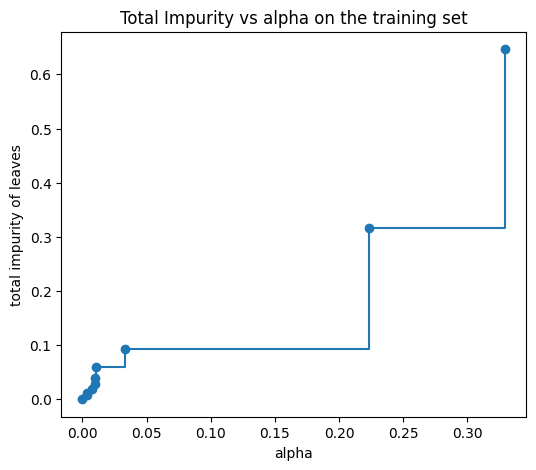

In [14]:
# Cost complexity pruning
tree_clf = DecisionTreeClassifier()
tree_clf.fit(X_train, y_train)
path = tree_clf.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(ccp_alphas, impurities, marker="o", drawstyle="steps-post")
ax.set_xlabel("alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs alpha on the training set")
plt.show()

Run the following code to understand the depth and number of nodes in each tree in the sequence.

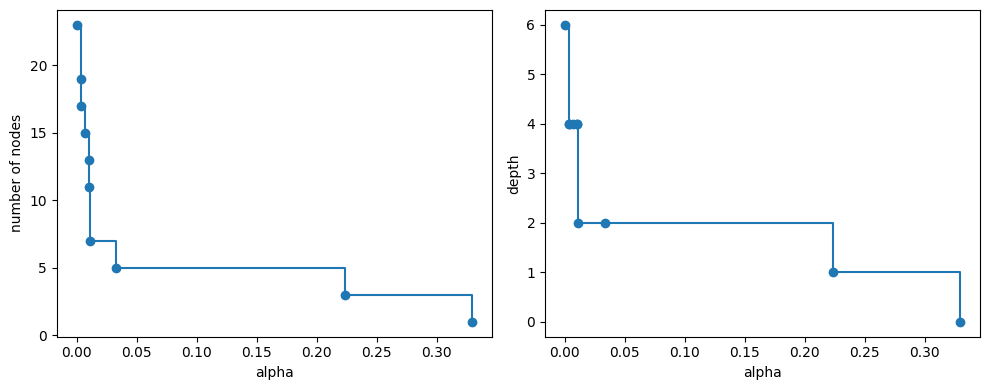

In [15]:
# Fit and store the decision tree for each value of alpha
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

# Plot the depth and number of nodes for each tree for in the sequence as a function of alpha
node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth")
fig.tight_layout()

We see that each $\alpha$ is associated with unique number of nodes and increasing $\alpha$ reduces the size of tree (number of nodes). Thus, it is often more intutive to plot the total impurity as a function of the tree size.

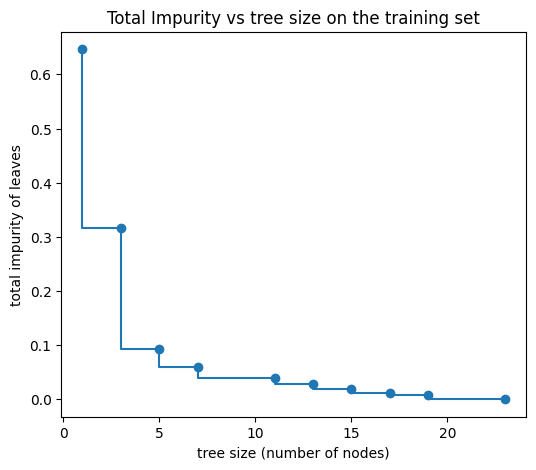

In [16]:
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(node_counts, impurities, marker="o", drawstyle="steps-post")
ax.set_xlabel("tree size (number of nodes)")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs tree size on the training set")
plt.show()

Run the following code to compute the accuracy of each tree in the sequence on both the training and test set. 

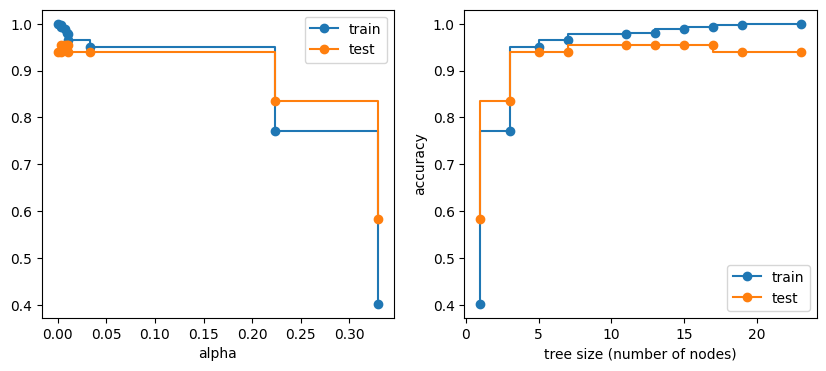

In [17]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

fig, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].set_xlabel("alpha")
ax[0].plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax[0].plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax[0].legend()
ax[1].set_xlabel("tree size (number of nodes)")
ax[1].set_ylabel("accuracy")
ax[1].plot(node_counts, train_scores, marker="o", label="train", drawstyle="steps-post")
ax[1].plot(node_counts, test_scores, marker="o", label="test", drawstyle="steps-post")
ax[1].legend()
plt.show()

The training accuracy is of course a decreasing function of $\alpha$ (or increasing function of tree size), since the tree becomes less complex as the $\alpha$ increases. Instead, the test accuracy is fairly flat for any $\alpha<0.2$ or tree size greater than 5. Of course, we can't use the test data to choose $\alpha$, as that would lead to **data leakage**!! Instead, we need to use cross-validation to tune the value of $\alpha$. 

### 🚩 Exercise 6 (CORE)

Run the following code to compute the cross-validated accuracy across the values of $\alpha$. 

- Add the cross-validated accuracy to the figure above with train and test accuracy.

- What is best value of $\alpha$ returned by the grid search and the corresponding size of the tree? Based on the plot, would you choose this value or a different one? Why?

In [18]:
# Grid search
clf = DecisionTreeClassifier()
gs = GridSearchCV(clf, 
                  param_grid = {'ccp_alpha': ccp_alphas}, 
                  cv = KFold(5, shuffle=True, random_state=42),)
gs.fit(X_train,y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'ccp_alpha': array([0. ..., 0.32942935])}"
,scoring,None
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


Best alpha from GridSearchCV: 0.00369
Corresponding tree size (number of nodes): 19


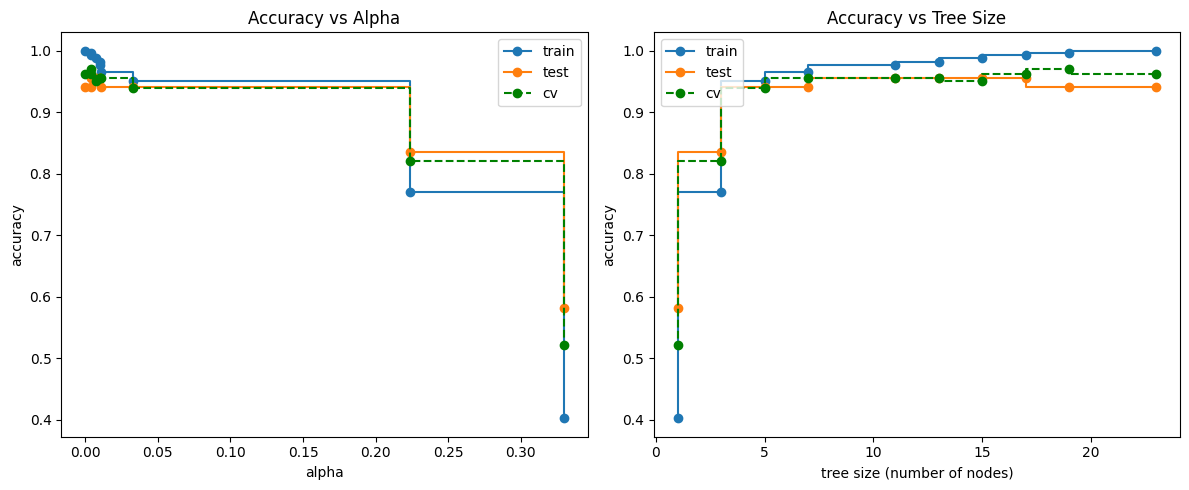

In [19]:
# Code for your answer here
cv_scores = gs.cv_results_['mean_test_score']
best_alpha = gs.best_params_['ccp_alpha']

best_index = list(ccp_alphas).index(best_alpha)
best_tree_size = node_counts[best_index]

print(f"Best alpha from GridSearchCV: {best_alpha:.5f}")
print(f"Corresponding tree size (number of nodes): {best_tree_size}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy vs Alpha
ax[0].plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax[0].plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax[0].plot(ccp_alphas, cv_scores, marker="o", label="cv", drawstyle="steps-post", linestyle="--", color="green")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("accuracy")
ax[0].set_title("Accuracy vs Alpha")
ax[0].legend()

# Accuracy vs Tree Size
ax[1].plot(node_counts, train_scores, marker="o", label="train", drawstyle="steps-post")
ax[1].plot(node_counts, test_scores, marker="o", label="test", drawstyle="steps-post")
ax[1].plot(node_counts, cv_scores, marker="o", label="cv", drawstyle="steps-post", linestyle="--", color="green")
ax[1].set_xlabel("tree size (number of nodes)")
ax[1].set_ylabel("accuracy")
ax[1].set_title("Accuracy vs Tree Size")
ax[1].legend()

plt.tight_layout()
plt.show()

_The grid search returned a best $\alpha$ of 0.00000, which corresponds to the fully unpruned tree with a size of 23 nodes.\
I would actually choose a different value, specifically an $\alpha$ that yields a much smaller tree. Why: While GridSearchCV automatically selects the parameter with the absolute highest cross-validation score (which happened to be the unpruned 23-node tree), the "Accuracy vs Tree Size" plot reveals a clear plateau. The cross-validated accuracy (green dashed line) jumps to roughly ~0.95 with a tree size of just 5 to 7 nodes. The tiny marginal gain in accuracy achieved by expanding the tree to 23 nodes is not worth the added complexity. Choosing a smaller tree (e.g., 5 to 7 nodes) provides a much simpler, more interpretable model that is less prone to overfitting, successfully applying the principle of parsimony (Occam's razor)._

### 🚩 Exercise 7 (CORE)

For your chosen value of $\alpha$ fit and visualize the tree. How does it compare to the shallow and deep tree that we initialy fit?

Chosen alpha: 0.01096


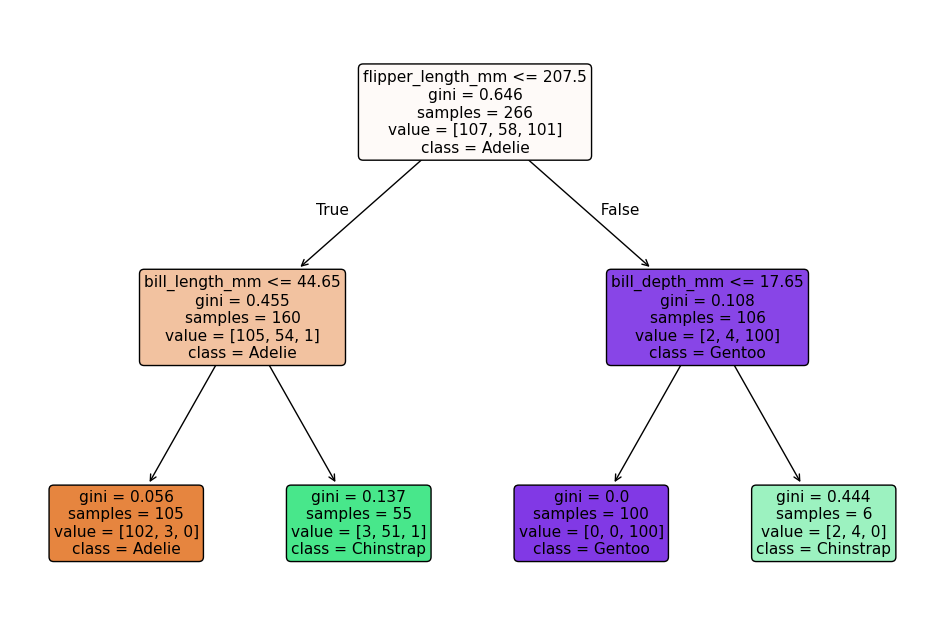

Depth of the pruned tree: 2
Number of nodes in pruned tree: 7


In [20]:
# NOTE: call your tree clf or change to your name of the pruned tree when computing feature importances before exercise 12

# Code for your answer here
target_nodes = 7
chosen_index = next(i for i, nodes in enumerate(node_counts) if nodes <= target_nodes)
chosen_alpha = ccp_alphas[chosen_index]

print(f"Chosen alpha: {chosen_alpha:.5f}")

clf = DecisionTreeClassifier(ccp_alpha=chosen_alpha, random_state=0)
clf.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
plot_tree(
    clf,
    filled=True,
    rounded=True,
    feature_names=X_train.columns,
    class_names=clf.classes_
)
plt.show()

print(f"Depth of the pruned tree: {clf.get_depth()}")
print(f"Number of nodes in pruned tree: {clf.tree_.node_count}")

_Compared to the Deep Tree (max_depth=10): The deep tree grew to 23 nodes and perfectly memorized the training set, which is a classic sign of overfitting. Our pruned tree is significantly smaller (only 7 nodes). By using Cost Complexity Pruning with an $\alpha$ of ~0.011, we successfully snipped off the weak, highly specific lower branches that were just fitting the noise in the data, leaving only the most robust and important splits.\
Compared to the Shallow Tree (max_depth=2): Interestingly, this pruned tree is structurally identical to the shallow tree we fit in Exercise 1. It has the exact same features, thresholds, and 7 total nodes. Our completely arbitrary guess to use max_depth=2 at the very beginning of the workshop actually happened to be the optimal, most robust tree shape for this specific dataset. While max_depth forces a hard stop, pruning proves mathematically that growing the tree any further than this isn't worth the cost in complexity._

# Ensembles <a id='majVot'></a> 

Ensembles combine the predictions of several base estimators to improve generalization and robustness, compared with a single estimator. A number of ensemble methods are available in `sklearn`, and for an overview, see 
https://scikit-learn.org/stable/modules/ensemble.html#. However, we only have time to cover a subset of ensemble methods, namely, **bagging**, **random forests**, and **voting**.

## Bagging

A bagging classifier is an ensemble of base classifiers, each fit on random subsets of a dataset. Their predictions are then pooled or aggregated to form a final prediction. To apply bagging to decision trees, we simply construct 
(i) decision trees using bootstrapped training sets,
(ii) agregated the predictions (either by averaging the probabilities or by majority vote).

Bagging is typically used as a way to reduce the variance of a high-variance estimator (e.g. a decision tree). The parameter `n_estimators` contols the number of bootstrapped datasets, and hence the number of estimators in the ensemble. While bagging is when sampling is performed with replacement, the `sklearn` implementation allows for more general constructions of the random subsets of the data: 

- Pasting is when the sampling is done without replacement and is designed to use smaller sample sizes than the training dataset (useful when the training dataset does not fit into memory). Pasting can be performed with `BaggingClassifier` by setting the options `bootstrap=FALSE` and `max_samples` either to an integer or a float representing the sample size of the random subset as a proportion of training points. 

- Random Subspaces is when random subsets of the dataset are drawn as random subsets of the features. Random Subspaces can be performed with `BaggingClassifier` by setting the options `bootstrap=FALSE` and `max_features` either to an integer or a float representing the number of features in the random subset as a proportion of the number of features in the training data. 

- Random Patches is when random subsets of the dataset are drawn based on random subsets of both the features and samples, and can be constructed by combining the options above. 

Averaging methods generally work best when the classifiers are diverse, and they have been shown to give impressive improvements in accuracy by combining together hundreds or even thousands of trees into a single procedure.

Note that while the default estimator in `BaggingClassifier` is a decision tree, other classifiers can be combined by specifying the option `estimator`. Also note that in `sklearn`'s implementation, the final predictions are obtained by averaging the prediction probabilities across estimators, with majority voting only used for estimators that don't provide probabilistic outputs. 

For more details, see:  
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html


### 🚩 Exercise 8  (CORE)

- Fit a bagged classifier to the data that combines 10 decision trees.

- Plot the confusion matrix on the both test and training data for both your pruned tree and bagged classifier. Comment on the advantages and disadvantages of the pruned tree vs bagged classifier briefly. 

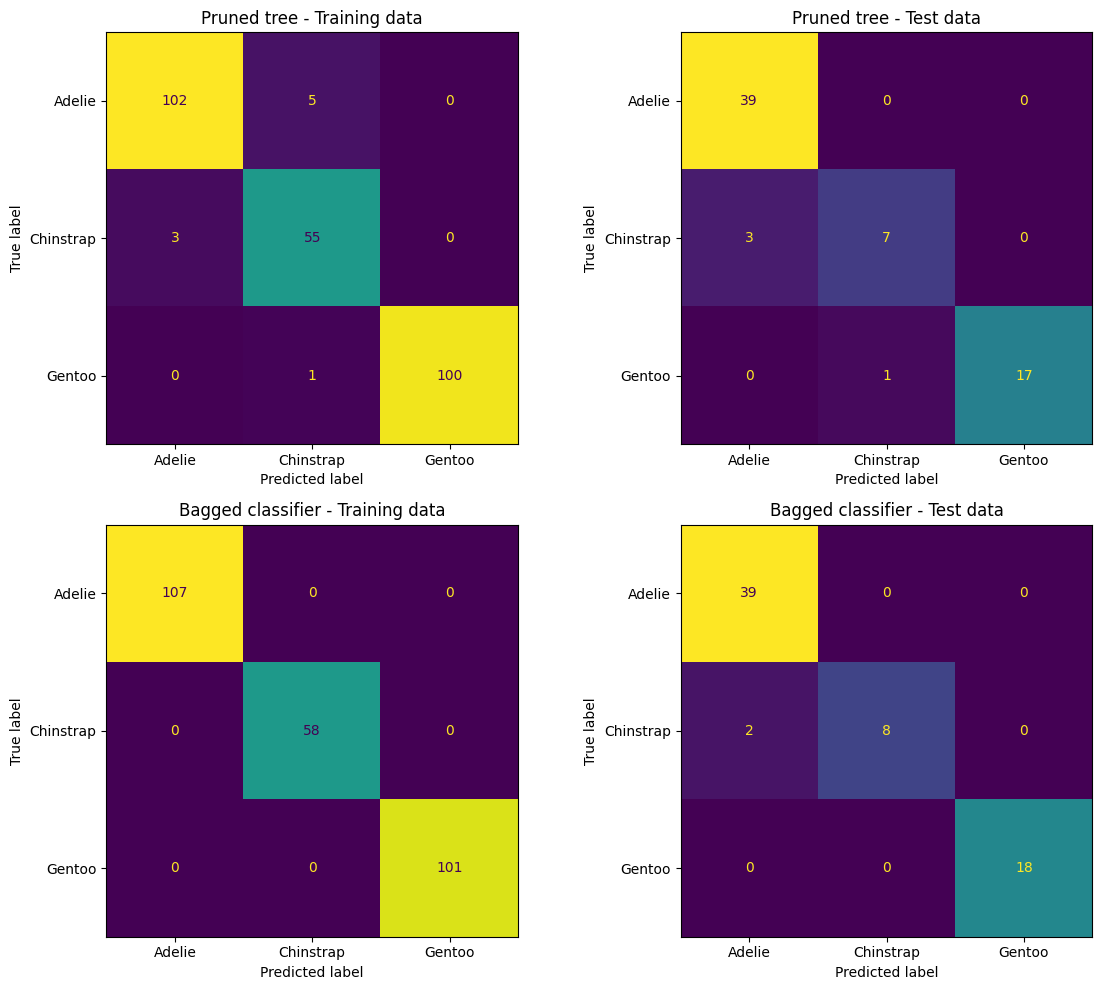

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# bagged classifier with 10 decision trees
bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=123),
    n_estimators=10,
    bootstrap=True,
    random_state=123
)
bag_clf.fit(X_train, y_train)


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ConfusionMatrixDisplay.from_estimator(
    clf, X_train, y_train, ax=axes[0, 0], colorbar=False
)
axes[0, 0].set_title("Pruned tree - Training data")

ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test, ax=axes[0, 1], colorbar=False
)
axes[0, 1].set_title("Pruned tree - Test data")

ConfusionMatrixDisplay.from_estimator(
    bag_clf, X_train, y_train, ax=axes[1, 0], colorbar=False
)
axes[1, 0].set_title("Bagged classifier - Training data")

ConfusionMatrixDisplay.from_estimator(
    bag_clf, X_test, y_test, ax=axes[1, 1], colorbar=False
)
axes[1, 1].set_title("Bagged classifier - Test data")

plt.tight_layout()
plt.show()

From the plot, we can find some results. The pruned tree works well, but there are still some mistakes. On the training data, a few Adelie penguins are predicted as Chinstrap, and one Gentoo is predicted as Chinstrap. On the test data, some Chinstrap penguins are predicted as Adelie.
The bagged classifier performs better on the training data. It almost classifies all samples correctly. On the test data, the results are also slightly better. For example, it correctly predicts more Chinstrap penguins than the pruned tree.The advantage of the bagged classifier is that it combines several trees, so the predictions are more stable and the variance is lower. This often improves performance.
The disadvantage is that the model is harder to interpret and needs more computation, because it trains many trees instead of only one.

### 🚩 Exercise 9  (CORE)

For the range of `n_estimators` provided below: 
- Fit the bagged trees and compute the training accuracy, test accuracy, and out-of-bag scores. 
- Plot all three metrics as a function of the number of estimators. 
- Comment on the results and suggest a suitable number of estimators for this data.

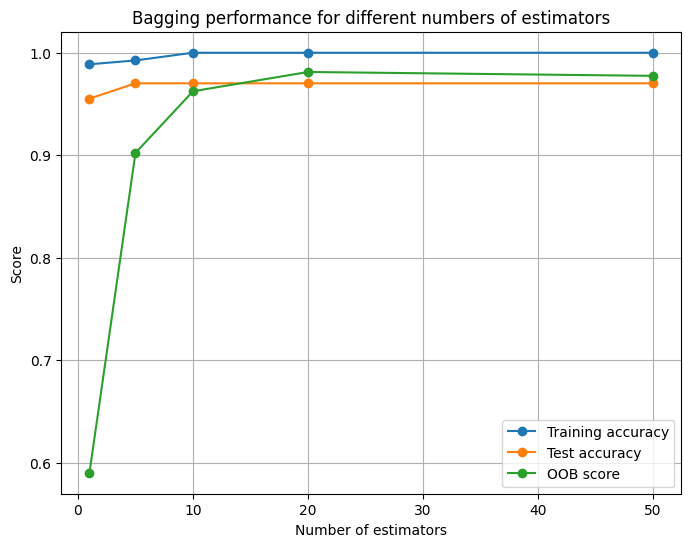

In [26]:
n_est = np.array([1,5,10,20,50],dtype=int)

# Code for your answer here
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

train_acc = []
test_acc = []
oob_scores = []

for n in n_est:
    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=123),
        n_estimators=n,
        bootstrap=True,
        oob_score=True,
        random_state=123
    )
    
    bag.fit(X_train, y_train)
    
    train_acc.append(bag.score(X_train, y_train))
    test_acc.append(bag.score(X_test, y_test))
    oob_scores.append(bag.oob_score_)

plt.figure(figsize=(8, 6))
plt.plot(n_est, train_acc, marker='o', label='Training accuracy')
plt.plot(n_est, test_acc, marker='o', label='Test accuracy')
plt.plot(n_est, oob_scores, marker='o', label='OOB score')

plt.xlabel("Number of estimators")
plt.ylabel("Score")
plt.title("Bagging performance for different numbers of estimators")
plt.legend()
plt.grid(True)
plt.show()

From the plot, the training accuracy is very high for all values of n_estimators. It quickly reaches 1.0 when the number of trees increases. This shows that the model can fit the training data very well.
The test accuracy improves slightly when the number of estimators increases from 1 to around 5 or 10. Then it stays almost the same. This means adding more trees does not give much improvement on the test data.
The OOB score also increases when the number of estimators grows. It becomes stable after about 10 to 20 trees. This suggests that the model performance stops improving after this point.
A suitable number of estimators for this dataset is around 10 or 20. At this point the test accuracy and OOB score are already high and stable, so using more trees will only increase computation without much benefit.

### Bagging: low diversity in estimators

Bagging alone may not produce very diverse trees, and thus may result in only modest improvements in accuracy.  In particular, if there is a strong set of predictors in the data, then the bagged trees will look quite similar to each other and predictions will be highly correlated. Averaging highly correlated quantities does not lead to a large reduction in variance and provides on very small improvements in predictions.

Run the following code below, the print out the feature and threshold used for the first split for each of the trees in our ensemble. Notice how most of trees use the same first splitting rule. 

In [28]:
# print out the first split for all trees in the bagged model
for i in range(10):
    print('Estimator: ', i+1, 
          ', First split feature: ', bag_clf.estimators_[i].tree_.feature[0], 
          ', First split threshold: ', bag_clf.estimators_[i].tree_.threshold[0])

Estimator:  1 , First split feature:  0 , First split threshold:  42.75
Estimator:  2 , First split feature:  2 , First split threshold:  207.5
Estimator:  3 , First split feature:  1 , First split threshold:  16.449999809265137
Estimator:  4 , First split feature:  2 , First split threshold:  207.0
Estimator:  5 , First split feature:  0 , First split threshold:  42.35000038146973
Estimator:  6 , First split feature:  2 , First split threshold:  207.0
Estimator:  7 , First split feature:  2 , First split threshold:  208.5
Estimator:  8 , First split feature:  2 , First split threshold:  207.5
Estimator:  9 , First split feature:  0 , First split threshold:  43.25
Estimator:  10 , First split feature:  2 , First split threshold:  207.5


## Random Forests

Random forests is one of the most widely used machine learning algorithms. A random forest is an ensemble that fits a number of decision tree classifiers on various random subsets of the data (Random Patches) and uses averaging to improve the predictive accuracy and control overfitting. Random forests are essentally bagged tree classifiers, but improve the diversity and decorrelate the trees compared with bagging by using a random sample of features each time a split in a tree is considered. The random forest algorithm can therefore be summarized as:

- Draw a random bootstrap sample of the training data.

- Grow a decision tree from the bootstrap data. At each node:
    * Randomly select a subset of features without replacement (defaults to the square root of the total number of features).
    * Split the node using the feature and threshold that provides the best split according to the objective function.

- Repeat the steps above for the desired number of bootstrapped datasets (estimators in the ensemble).

- Aggregate the predictions (`sklearn`'s `RandomForestClassifier` aggregates the prediction probabilities).

### Parameters

Important parameters include:

- `max_features`: specifies that number of random features to consider at each split. If set to the total number of features, then it is simply bagging. 
- `n_estimators`: number of trees in the ensemble; larger is generally better as averaging more trees will yield a more robust ensemble. 
- `max_samples`: sample size of the bootstrap dataset (useful when the training set is large to reduce memory and computational cost).

 By default, large and complex trees are grown for each bootstrapped data. While these trees tend to have high variance and overfit to the training data, aggregation reduces variance and improves predictive accuracy. If desired, the complexity of the trees can also be limited by setting the parameters of the decision trees  (e.g. `max_depth`, `max_leaf_nodes`); again this may be useful to reduce memory and computational cost.

### 🚩 Exercise 10 (CORE)

- Fit a random forest classifer that includes 10 trees in the ensemble. 
- Print the splitting rule (feature and threshold) for each estimator. How does this compare to the bagged model?

In [29]:
from sklearn.ensemble import RandomForestClassifier

# fit random forest with 10 trees
rf = RandomForestClassifier(
    n_estimators=10,
    random_state=123
)

rf.fit(X_train, y_train)

# print first split rule for each tree
for i in range(10):
    print(
        "Estimator:", i+1,
        ", First split feature:", rf.estimators_[i].tree_.feature[0],
        ", First split threshold:", rf.estimators_[i].tree_.threshold[0]
    )

Estimator: 1 , First split feature: 0 , First split threshold: 42.75
Estimator: 2 , First split feature: 2 , First split threshold: 207.5
Estimator: 3 , First split feature: 2 , First split threshold: 207.5
Estimator: 4 , First split feature: 2 , First split threshold: 207.0
Estimator: 5 , First split feature: 0 , First split threshold: 42.35000038146973
Estimator: 6 , First split feature: 2 , First split threshold: 207.0
Estimator: 7 , First split feature: 2 , First split threshold: 208.5
Estimator: 8 , First split feature: 2 , First split threshold: 207.5
Estimator: 9 , First split feature: 0 , First split threshold: 43.25
Estimator: 10 , First split feature: 1 , First split threshold: 16.449999809265137


From the output, we can fin that the first split rule is different across many trees in the random forest. Some trees use feature 0, some use feature 2, and others use different thresholds. This shows that the trees in the random forest are more diverse.
In the bagged model, many trees often use the same feature and similar thresholds for the first split. This means the trees are more similar to each other.
The random forest reduces this problem by randomly selecting a subset of features at each split. Because of this, different trees may choose different features and thresholds. This increases the diversity of the trees and usually improves the overall performance of the model.

### 🚩 Exercise 11 (CORE)

- Fit a random forest to your data, using the OOB error to tune the number of features considered at each split, for **max_features** in $[2, 3, 4]$. What is the optimal number of features?
- Visualize the confusion matrix on the train and test data. 

In [ ]:
# Note: let rf be the name your random forest object with the optimal max_features or change the name in exercise 12

# Code for your answer here


### Feature Importance <a id='feImport'></a> 

The fitted `RandomForestClassifier` also has an attribute `feature_importances_`, that reflects the relative rank (i.e. depth) and predictive power of a feature, averaged across all trees in the ensemble. For further details, see https://scikit-learn.org/stable/modules/ensemble.html#feature-importance-evaluation, and for an example, see https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html.

Let's start by visualizing the feature importances for our pruned tree in exercise 7 (note: replace `clf` with the name of your tree from exercise 7, if not already called `clf`). Notice how this reflects the depth of the feature and impurity decrease.

In [ ]:
# NOTE: change clf to name of your pruned tree in exercise 7

# Extract feature names
feature_names = clf.feature_names_in_ 

# Create a pandas series with the feature importances
importances = pd.Series(
    clf.feature_importances_, index=feature_names
).sort_values(ascending=True)

# Plot the feature importances
ax = importances.plot.barh()
ax.set_title("Decision Tree: Feature Importances")
ax.figure.tight_layout()


### 🚩 Exercise 12 (CORE)

- Run the following code to plot the feature importance (averaged across all trees along with the standard deviation). 
- Visualize the correlation matrix of the features. 
- Has the ranking of the features changed comparing the pruned tree to the random forest? Does the correlation matrix provide any insight on why?

In [ ]:
# Note: change rf to the name your random forest object in exercise 12

# Compute the standard deviation 
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

# Create a pandas series with the feature importances
importances_rf = pd.Series(
    rf.feature_importances_, index=feature_names
).sort_values(ascending=True)

# Plot the feature importances
ax = importances_rf.plot.barh(xerr=std)
ax.set_title("Random Forest: Feature Importances")
ax.figure.tight_layout()

In [ ]:
# Code for your answer here

_Type your answer here_

## Voting Classifier

While bagging and random forests focused on creating an ensemble of the same estimator (e.g. trees) fit on different random subsets of the data, the idea behind **voting** is to combine different estimators. The predictions then can be aggregated either by using a majority vote or by averaging predicted probabilities (soft vote). This can be useful for a set of equally well performing models in order to balance out their individual weaknesses.

In the `VotingClassifier`, the default is to aggregate predictions with **hard voting** (i.e. `voting='hard'` by default), which simply looks at the tally of votes received by each class across the estimators in the ensemble. Instead, **soft voting** (i.e. `voting='soft'`) averages the predicted probabilities across the estimators in the ensemble.

For further details, please see the documentation from here: https://scikit-learn.org/stable/modules/ensemble.html#voting-classifier

### 🚩 Exercise 13  (EXTRA)

- Create a voting classifier that combines your pruned tree, random forests, logistic regression, and support vector classifier.

- How does the accuracy on the test data compare across each model individually and the voting classifier?

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# Code for your answer here

_Type your answer here_

# Competing the Worksheet

At this point you have hopefully been able to complete all the CORE exercises and attempted the EXTRA ones. Now 
is a good time to check the reproducibility of this document by restarting the notebook's
kernel and rerunning all cells in order.

Before generating the PDF, please **change 'Student 1' and 'Student 2' at the top of the notebook to include your name(s)**.

Once that is done and you are happy with everything, you can then run the following cell 
to generate your PDF. Once generated, please submit this PDF on Learn page by 16:00 PM on the Friday of the week the workshop was given. 

In [ ]:
!jupyter nbconvert --to pdf mlp_week08.ipynb 